# Cross-parameterization R² — Qwen 3.5 9B — All HMMs

In [1]:
import os
os.environ['HF_HOME'] = '/workspace/hf_cache'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import gc
import shutil
import numba
from tqdm import tqdm
from sklearn.model_selection import train_test_split

sns.set_context('notebook')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42); torch.manual_seed(42)

SEQ_LEN = 20_000
PROBE_START = 15_000
N_SEEDS = 10
TRAIN_FRAC = 0.2
CHUNK_SIZE = 4096

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
CROSS_CSV = os.path.join(RESULTS_DIR, 'cross_qwen35_9b.csv')


## Model

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = 'Qwen/Qwen3.5-9B'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16,
    attn_implementation='sdpa', device_map='auto')
model.eval()

N_LAYERS = len(model.model.layers)
LAYERS = list(range(N_LAYERS))
print(f'Model: {MODEL_NAME}')
print(f'Layers: {N_LAYERS}, hidden_size: {model.config.hidden_size}')

for name in ['F', 'Q', 'V']:
    tid = tokenizer.encode(f' {name}', add_special_tokens=False)[-1]
    decoded = tokenizer.decode([tid])
    print(f'  {name} -> id={tid} -> decoded="{decoded}"')


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Model: Qwen/Qwen3.5-9B
Layers: 32, hidden_size: 4096
  F -> id=426 -> decoded=" F"
  Q -> id=1167 -> decoded=" Q"
  V -> id=629 -> decoded=" V"


## Infrastructure

In [3]:
def stationary_distribution(T_matrices):
    T_full = sum(T_matrices)
    eigvals, eigvecs = np.linalg.eig(T_full.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    return pi / pi.sum()

def sample_hmm_sequence(T_matrices, pi, seq_len, seed=None):
    rng = np.random.default_rng(seed)
    n_states, n_tokens = len(pi), len(T_matrices)
    state = rng.choice(n_states, p=pi)
    tokens = []
    for _ in range(seq_len):
        tp = np.array([T_matrices[z][state].sum() for z in range(n_tokens)])
        tp /= tp.sum()
        z = rng.choice(n_tokens, p=tp)
        tokens.append(z)
        nsp = T_matrices[z][state] / T_matrices[z][state].sum()
        state = rng.choice(n_states, p=nsp)
    return np.array(tokens)

def tokens_to_prompt(tokens, token_names, sep=' '):
    return sep + sep.join(token_names[t] for t in tokens)

def tokenize_prompt(prompt):
    return tokenizer.encode(prompt, return_tensors='pt', truncation=False)

def match_positions(input_ids, tok_ids):
    ids = input_ids[0].cpu().numpy()
    tok_id_set = {tid: zi for zi, tid in enumerate(tok_ids)}
    pos, tok = [], []
    for i, tid in enumerate(ids):
        if tid in tok_id_set:
            pos.append(i); tok.append(tok_id_set[tid])
    return np.array(pos), np.array(tok)

@numba.njit(cache=True)
def full_bayesian_beliefs_numba(tokens, T_stack, pi):
    n = len(tokens)
    n_states = len(pi)
    beliefs = np.zeros((n, n_states))
    b = pi.copy()
    for t in range(n):
        b = b @ T_stack[tokens[t]]
        s = 0.0
        for j in range(n_states):
            s += b[j]
        if s > 0:
            for j in range(n_states):
                b[j] /= s
        for j in range(n_states):
            beliefs[t, j] = b[j]
    return beliefs

def chunked_forward_with_hooks(input_ids, layers, probe_start):
    seq_len = input_ids.shape[1]
    acts = {l: [] for l in layers}
    past_kv = None
    first_hooked_chunk = None

    for start in range(0, seq_len, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, seq_len)
        chunk = input_ids[:, start:end].to(device)
        need_hooks = (end > probe_start)
        hooks = []
        chunk_acts = {}

        if need_hooks:
            if first_hooked_chunk is None:
                first_hooked_chunk = start
            for l in layers:
                def make_hook(li):
                    def fn(module, inp, out):
                        h = out[0] if isinstance(out, tuple) else out
                        chunk_acts[li] = h.half().cpu()
                    return fn
                hooks.append(model.model.layers[l].register_forward_hook(make_hook(l)))

        with torch.no_grad():
            out = model.model(chunk, past_key_values=past_kv, use_cache=True)

        for h in hooks:
            h.remove()
        if need_hooks:
            for l in layers:
                acts[l].append(chunk_acts[l][0])

        past_kv = out.past_key_values
        del out, chunk_acts; torch.cuda.empty_cache()

    del past_kv; torch.cuda.empty_cache()

    if first_hooked_chunk is None:
        first_hooked_chunk = 0
    acts_cat = {l: torch.cat(acts[l], dim=0).numpy() for l in layers}
    return acts_cat, first_hooked_chunk

def extract_late_activations(acts_cat, pos_indices, n_matched, probe_start, first_hooked_chunk, layers):
    late_mask = np.arange(n_matched) >= probe_start
    late_pos_idx = pos_indices[late_mask] - first_hooked_chunk
    n_late = int(late_mask.sum())
    acts_final = {l: acts_cat[l][late_pos_idx] for l in layers}
    return acts_final, n_late

# Warmup numba
_d = np.random.rand(3, 4, 4); _p = np.array([0.25, 0.25, 0.25, 0.25])
_ = full_bayesian_beliefs_numba(np.array([0, 1, 2], dtype=np.int64), _d, _p)
del _d, _p
print('Infrastructure loaded. Numba compiled.')


Infrastructure loaded. Numba compiled.


## HMM Definitions

In [4]:
# ===== Spiral (2 tokens, 3 states) =====

def spiral_matrices(a):
    return [
        np.array([[0.2*a, 0, 0], [0, 0, 0], [0.25*(1-a), 0, 0.5*a]]),
        np.array([[0.8*a, 1-a, 0], [0, a, 1-a], [0.75*(1-a), 0, 0.5*a]]),
    ]

# ===== Wing (2 tokens, 3 states) =====

def wing_matrices(x, y):
    b = (1 - x) / 2
    return [
        np.array([[0, b, 0], [0, y*x, 0.5*b], [b, 0, 0]]),
        np.array([[x, 0, b], [b, (1-y)*x, 0.5*b], [0, b, x]]),
    ]

# ===== Strata (2 tokens, 3 states) =====

def strata_matrices(a, t0, t1):
    b = (1 - a) / 2
    return [
        np.array([[t0*a, 0, 0], [0, t1*a, 0], [0, 0, 0]]),
        np.array([[(1-t0)*a, b, b], [b, (1-t1)*a, b], [b, b, a]]),
    ]

# ===== Arch (3 tokens, 4 states) =====

def arch_matrices(a):
    b = (1 - a) / 3
    return [
        np.array([[0.8*a,0,0,0],[0,0.2*a,0,0],[0,0,0.4*a,0],[0,0,0,0.6*a]]),
        np.array([[0,0,0,0],[0,0.4*a,0,0.4*b],[0,0,0.3*a,0],[0,0,0,0.16*a]]),
        np.array([[0.2*a,b,b,b],[b,0.4*a,b,0.6*b],[b,b,0.3*a,b],[b,b,b,0.24*a]]),
    ]

# ===== Mess3 (3 tokens, 3 states) =====

def mess3_matrices(a, x):
    b = (1 - a) / 2
    y = 1 - 2 * x
    ay, bx, by, ax = a*y, b*x, b*y, a*x
    return [
        np.array([[ay,bx,bx],[ax,by,bx],[ax,bx,by]]),
        np.array([[by,ax,bx],[bx,ay,bx],[bx,ax,by]]),
        np.array([[by,bx,ax],[bx,by,ax],[bx,bx,ay]]),
    ]

print('All HMM functions defined.')


All HMM functions defined.


## HMM Registry

In [5]:
HMMS = {
    'Spiral': {
        'fn': spiral_matrices,
        'params': [(a,) for a in np.arange(0.01, 0.11, 0.01).round(2)],
        'label_fn': lambda p: f'a={p[0]}',
        'token_names': np.array(['F', 'Q']),
    },
    'Wing': {
        'fn': wing_matrices,
        'params': [(x, 0.4) for x in np.arange(0.90, 1.00, 0.01).round(2)],
        'label_fn': lambda p: f'x={p[0]}, y={p[1]}',
        'token_names': np.array(['F', 'Q']),
    },
    'Strata': {
        'fn': strata_matrices,
        'params': [(a, 0.38, 0.54) for a in np.arange(0.90, 1.00, 0.01).round(2)],
        'label_fn': lambda p: f'a={p[0]}, t0={p[1]}, t1={p[2]}',
        'token_names': np.array(['F', 'Q']),
    },
    'Arch': {
        'fn': arch_matrices,
        'params': [(a,) for a in np.arange(0.90, 1.00, 0.01).round(2)],
        'label_fn': lambda p: f'a={p[0]}',
        'token_names': np.array(['F', 'Q', 'V']),
    },
    'Mess3': {
        'fn': mess3_matrices,
        'params': [
            (0.005, 0.01), (0.005, 0.02), (0.01, 0.02), (0.05, 0.02), (0.10, 0.02),
            (0.60, 0.02), (0.70, 0.02), (0.80, 0.02), (0.85, 0.02), (0.90, 0.02),
        ],
        'label_fn': lambda p: f'a={p[0]}, x={p[1]}',
        'token_names': np.array(['F', 'Q', 'V']),
    },
}

for name, cfg in HMMS.items():
    T = cfg['fn'](*cfg['params'][0])
    print(f'{name:>8}: {len(cfg["params"])} params, {len(T)} tokens, {T[0].shape[0]} states')


  Spiral: 10 params, 2 tokens, 3 states
    Wing: 10 params, 2 tokens, 3 states
  Strata: 10 params, 2 tokens, 3 states
    Arch: 10 params, 3 tokens, 4 states
   Mess3: 10 params, 3 tokens, 3 states


## Extract activations + Cross-R² (all HMMs, CSV-resumable)

In [6]:
# ---- Resume from CSV ----
if os.path.exists(CROSS_CSV):
    cross_df_prev = pd.read_csv(CROSS_CSV)
    done_hmms = set(cross_df_prev['hmm'].unique())
    print(f'Resumed: {done_hmms} already done')
else:
    cross_df_prev = pd.DataFrame()
    done_hmms = set()

cross_chunks = []

for hmm_name, cfg in HMMS.items():
    if hmm_name in done_hmms:
        print(f'\n===== {hmm_name} (done, skipping) =====')
        continue

    print(f'\n===== {hmm_name} =====')
    token_names = cfg['token_names']
    n_tok = len(token_names)
    tok_ids = [tokenizer.encode(f' {n}', add_special_tokens=False)[-1] for n in token_names]
    param_labels = [cfg['label_fn'](p) for p in cfg['params']]
    n_states = cfg['fn'](*cfg['params'][0])[0].shape[0]

    pbar = tqdm(total=len(cfg['params']) * N_SEEDS, desc=f'{hmm_name}')

    for seed in range(N_SEEDS):
        # ---- Extract activations for all params, this seed ----
        data = {}
        for param in cfg['params']:
            label = cfg['label_fn'](param)
            T_real = cfg['fn'](*param)
            pi_real = stationary_distribution(T_real)

            tokens = sample_hmm_sequence(T_real, pi_real, SEQ_LEN, seed=seed)
            prompt = tokens_to_prompt(tokens, token_names)
            input_ids = tokenize_prompt(prompt)
            pos_indices, tok_at_pos = match_positions(input_ids, tok_ids)
            n_matched = min(len(tokens), len(pos_indices))
            pos_indices = pos_indices[:n_matched]
            tok_at_pos = tok_at_pos[:n_matched]

            acts_cat, fhc = chunked_forward_with_hooks(input_ids, LAYERS, PROBE_START)
            acts_final, n_late = extract_late_activations(
                acts_cat, pos_indices, n_matched, PROBE_START, fhc, LAYERS)
            del acts_cat

            data[label] = {
                'tok_at_pos': tok_at_pos[:n_matched],
                'activations': acts_final,
                'n': n_late,
                'probe_start': PROBE_START,
            }
            pbar.set_postfix(seed=seed, param=label)
            pbar.update(1)

        gc.collect(); torch.cuda.empty_cache()

        # ---- Precompute beliefs for all params, this seed ----
        beliefs = {}
        for param in cfg['params']:
            label = cfg['label_fn'](param)
            T = cfg['fn'](*param)
            T_stack = np.stack(T)
            pi = stationary_distribution(T)
            d = data[label]
            b = full_bayesian_beliefs_numba(
                d['tok_at_pos'][:d['probe_start'] + d['n']].astype(np.int64),
                T_stack, pi)
            beliefs[label] = b[d['probe_start']:]

        # ---- Cross-R² for this seed ----
        n = list(data.values())[0]['n']
        idx_tr, idx_te = train_test_split(np.arange(n), train_size=TRAIN_FRAC, random_state=seed)

        for layer in LAYERS:
            for label_train in param_labels:
                X_tr = torch.tensor(data[label_train]['activations'][layer][idx_tr],
                                   device=device, dtype=torch.float32)
                Y_tr = torch.tensor(beliefs[label_train][idx_tr], device=device, dtype=torch.float32)

                P = torch.linalg.pinv(X_tr)
                W_probe = P @ Y_tr

                for label_test in param_labels:
                    X_te = torch.tensor(data[label_test]['activations'][layer][idx_te],
                                       device=device, dtype=torch.float32)
                    Y_te = torch.tensor(beliefs[label_test][idx_te], device=device, dtype=torch.float32)

                    pred = X_te @ W_probe
                    ss_res = ((Y_te - pred) ** 2).sum().item()
                    ss_tot = ((Y_te - Y_te.mean(0)) ** 2).sum().item()

                    cross_chunks.append({
                        'hmm': hmm_name, 'train': label_train, 'test': label_test,
                        'layer': layer, 'seed': seed,
                        'R2': 1.0 - ss_res / ss_tot,
                        'self': label_train == label_test,
                    })

                del X_tr, Y_tr, P, W_probe
                torch.cuda.empty_cache()

        del data, beliefs
        gc.collect(); torch.cuda.empty_cache()

    pbar.close()

    # Save CSV after each HMM family
    cross_new = pd.DataFrame(cross_chunks)
    pd.concat([cross_df_prev, cross_new], ignore_index=True).to_csv(CROSS_CSV, index=False)
    print(f'  Saved ({hmm_name} done)')

print(f'\nAll done.')



===== Spiral =====


Spiral: 100%|██████████| 100/100 [2:02:29<00:00, 73.50s/it, param=a=0.1, seed=9]   


  Saved (Spiral done)

===== Wing =====


Wing: 100%|██████████| 100/100 [2:05:41<00:00, 75.42s/it, param=x=0.99, y=0.4, seed=9]  


  Saved (Wing done)

===== Strata =====


...

  Saved (Strata done)

===== Arch =====


Arch: 100%|██████████| 100/100 [1:25:22<00:00, 51.23s/it, param=a=0.99, seed=9]  


  Saved (Arch done)

===== Mess3 =====


Mess3: 100%|██████████| 100/100 [46:31<00:00, 27.91s/it, param=a=0.9, x=0.02, seed=9]   


  Saved (Mess3 done)

All done.


## Load results (after restart)

In [7]:
cross_df = pd.read_csv(CROSS_CSV)
print(f'cross_df: {len(cross_df)} rows, HMMs: {cross_df["hmm"].unique()}')


cross_df: 160000 rows, HMMs: <StringArray>
['Spiral', 'Wing', 'Strata', 'Arch', 'Mess3']
Length: 5, dtype: str


## Heatmaps

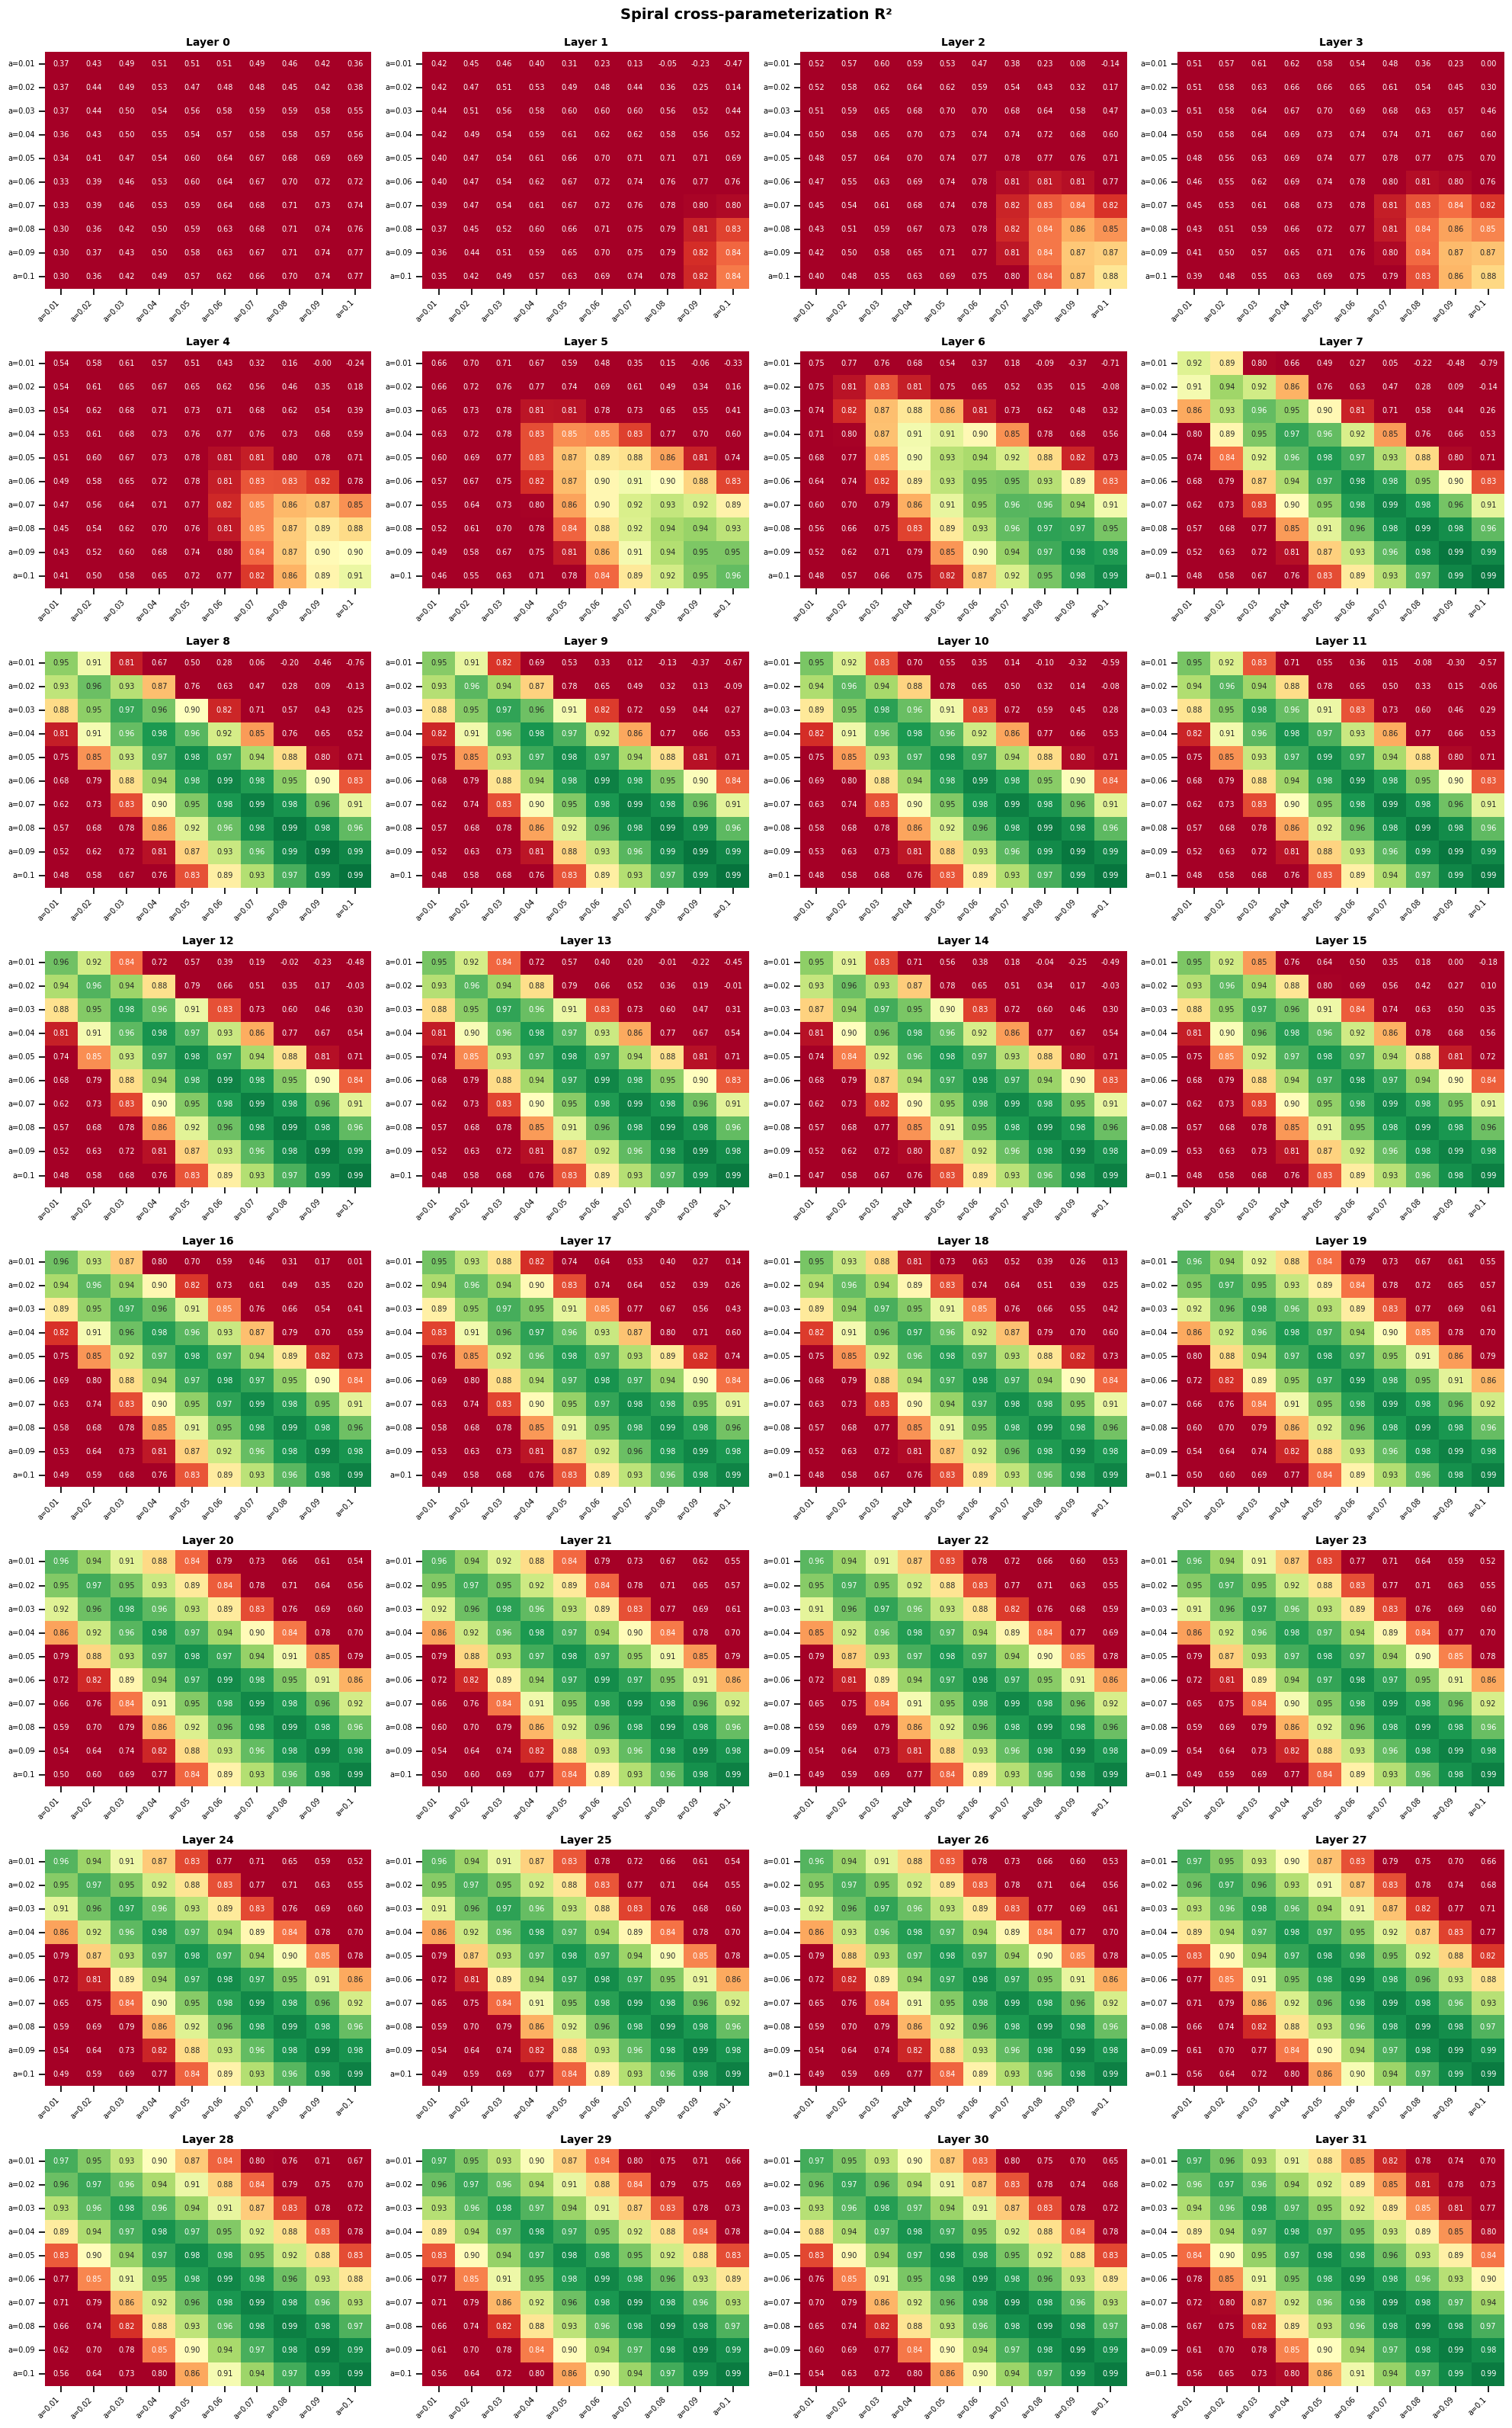

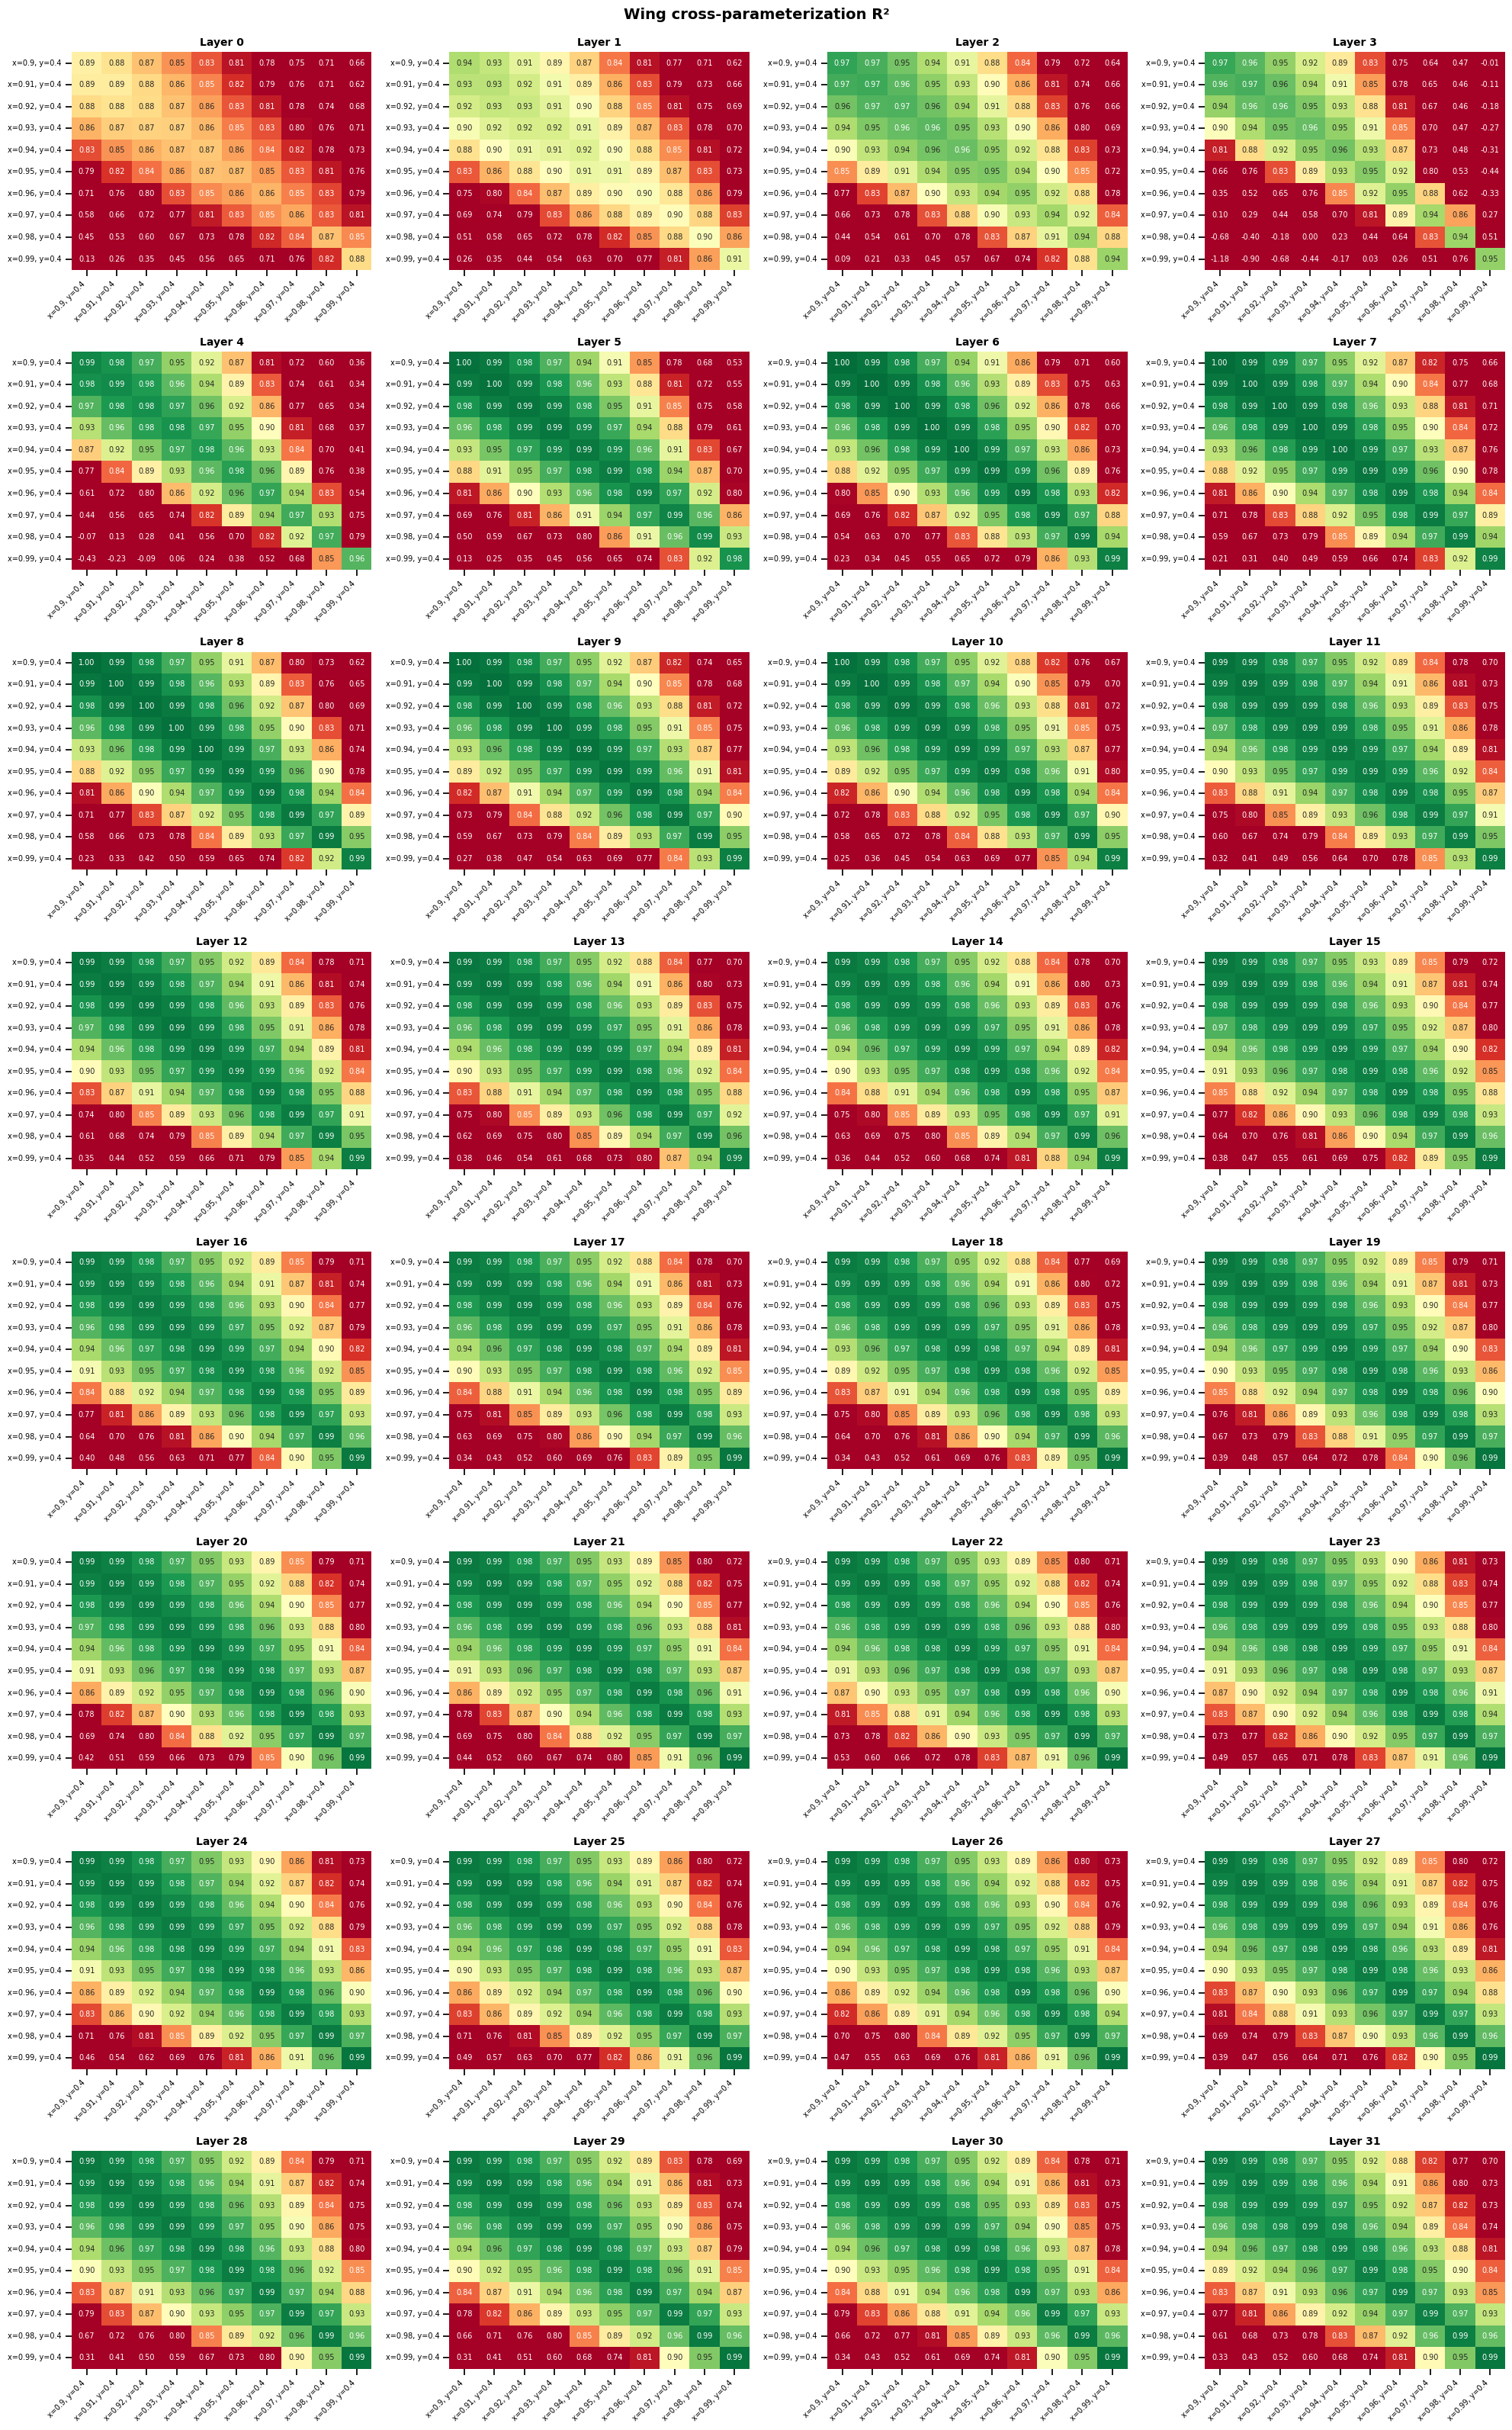

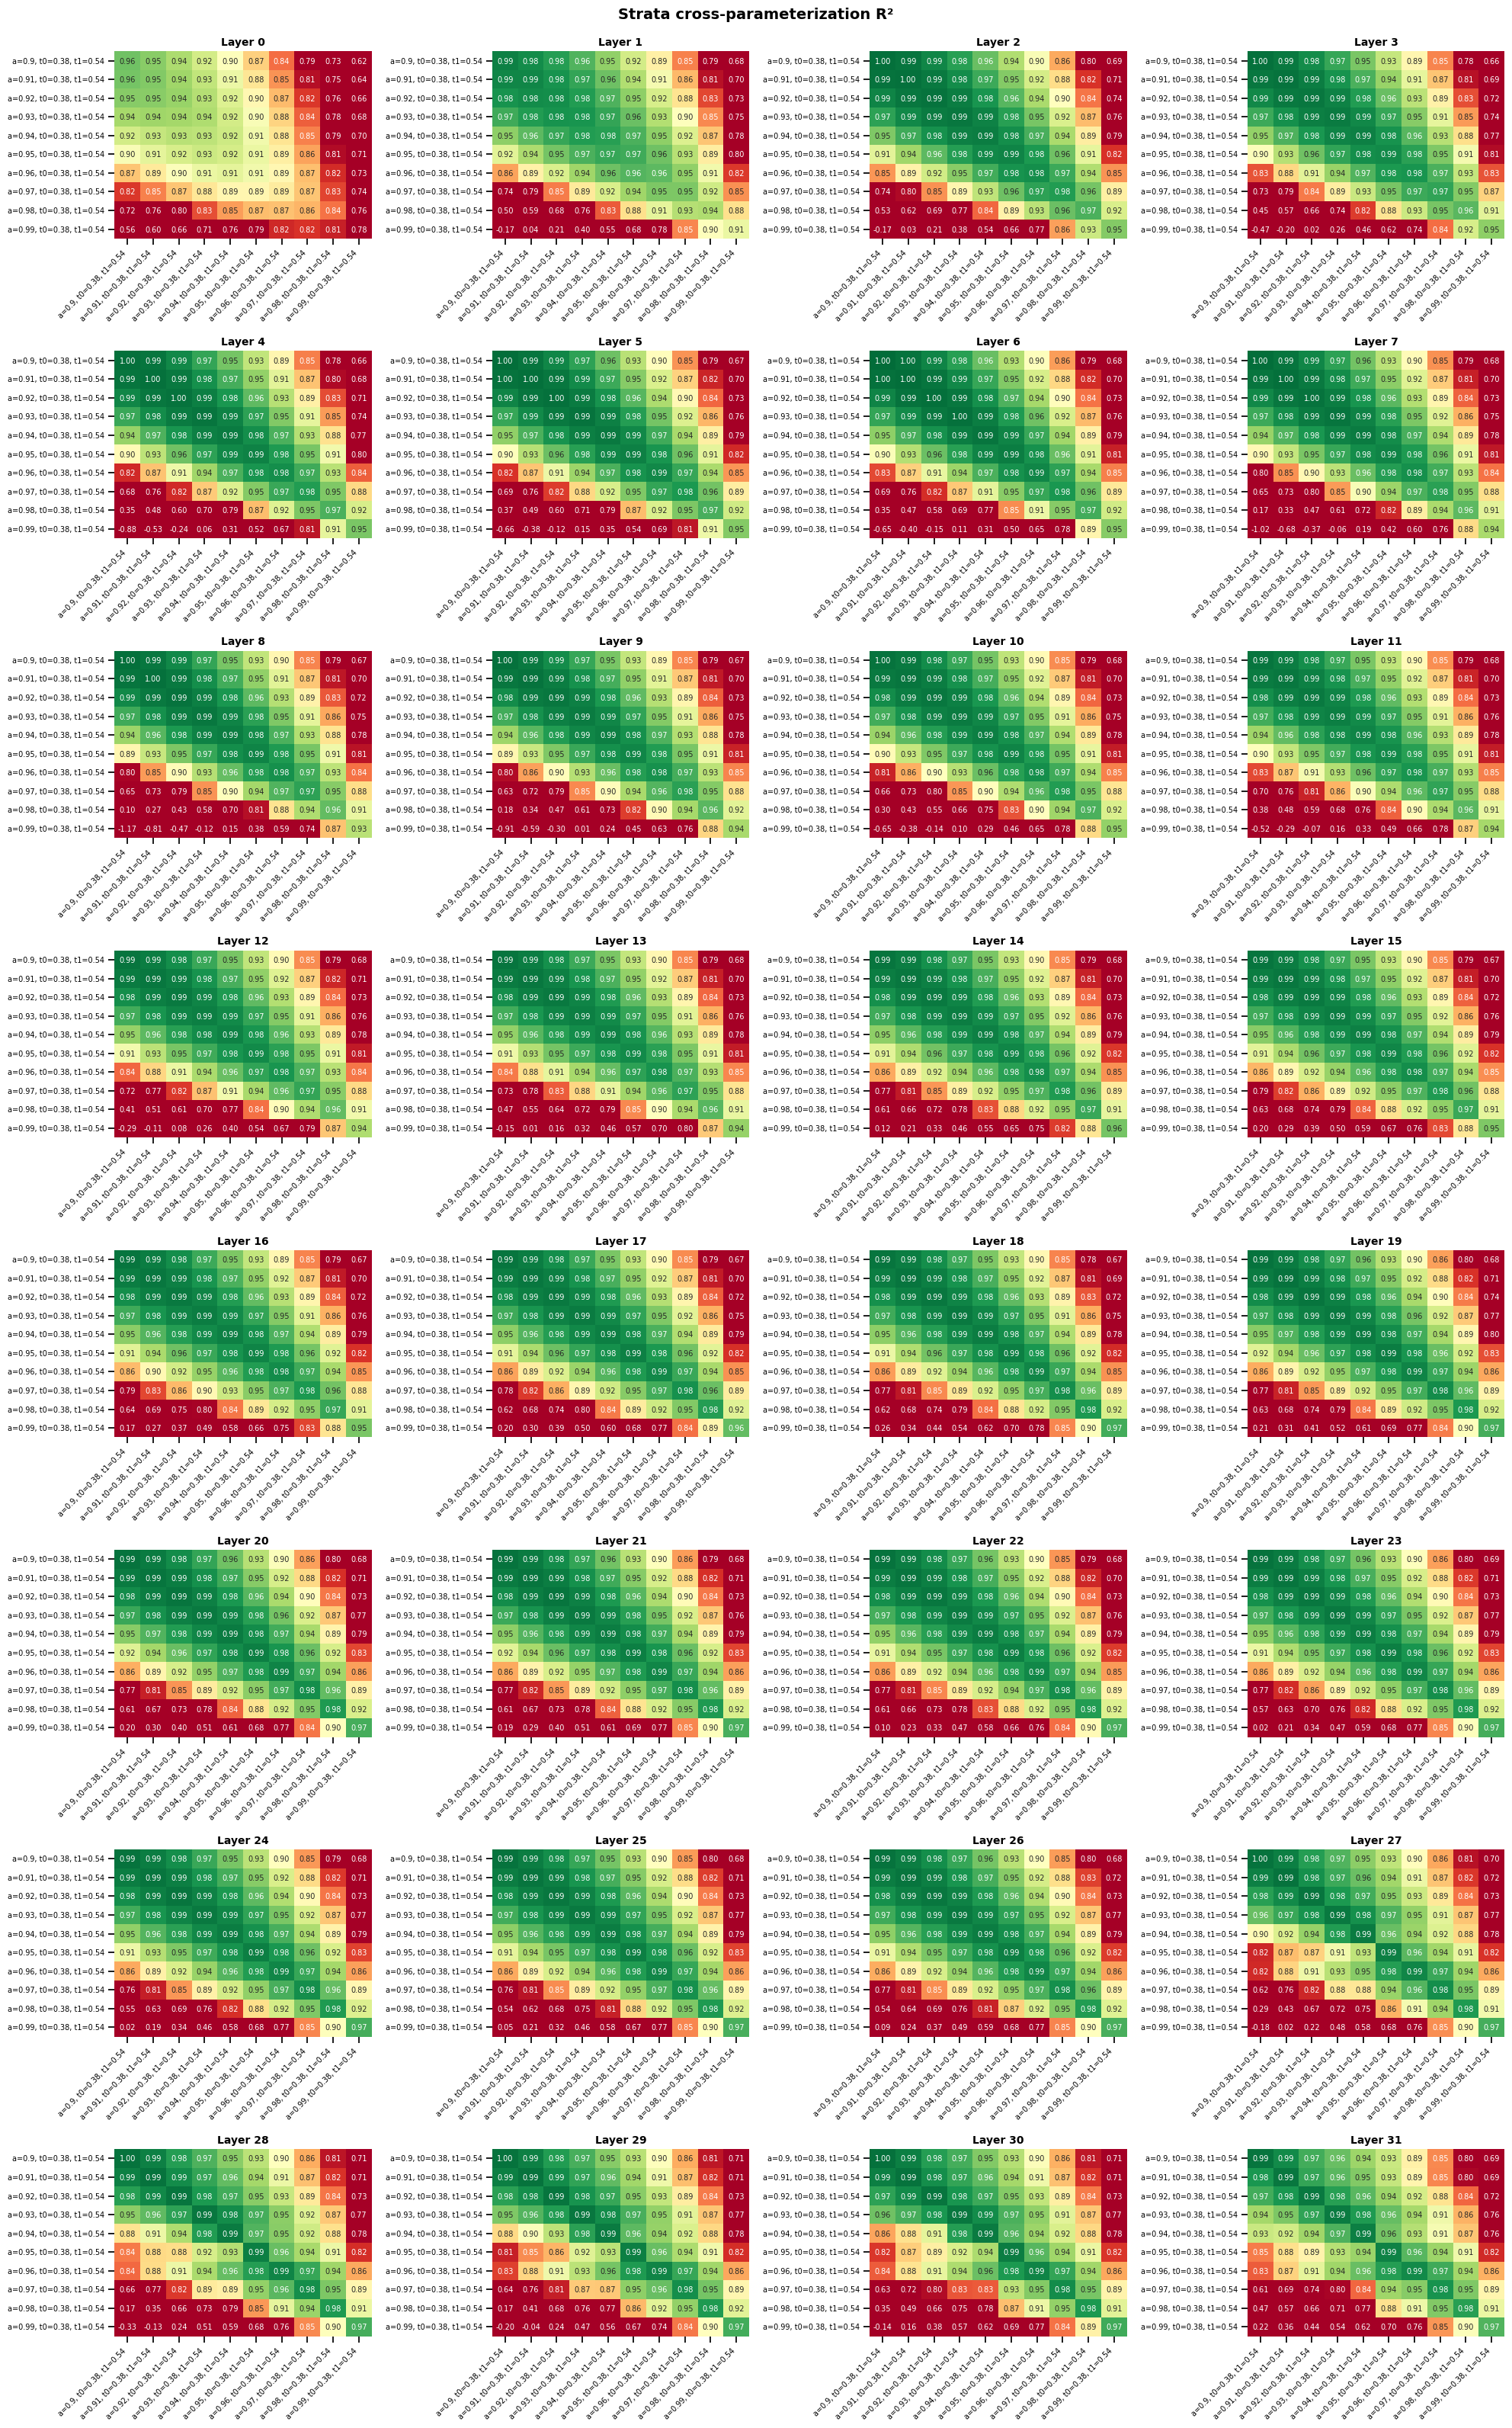

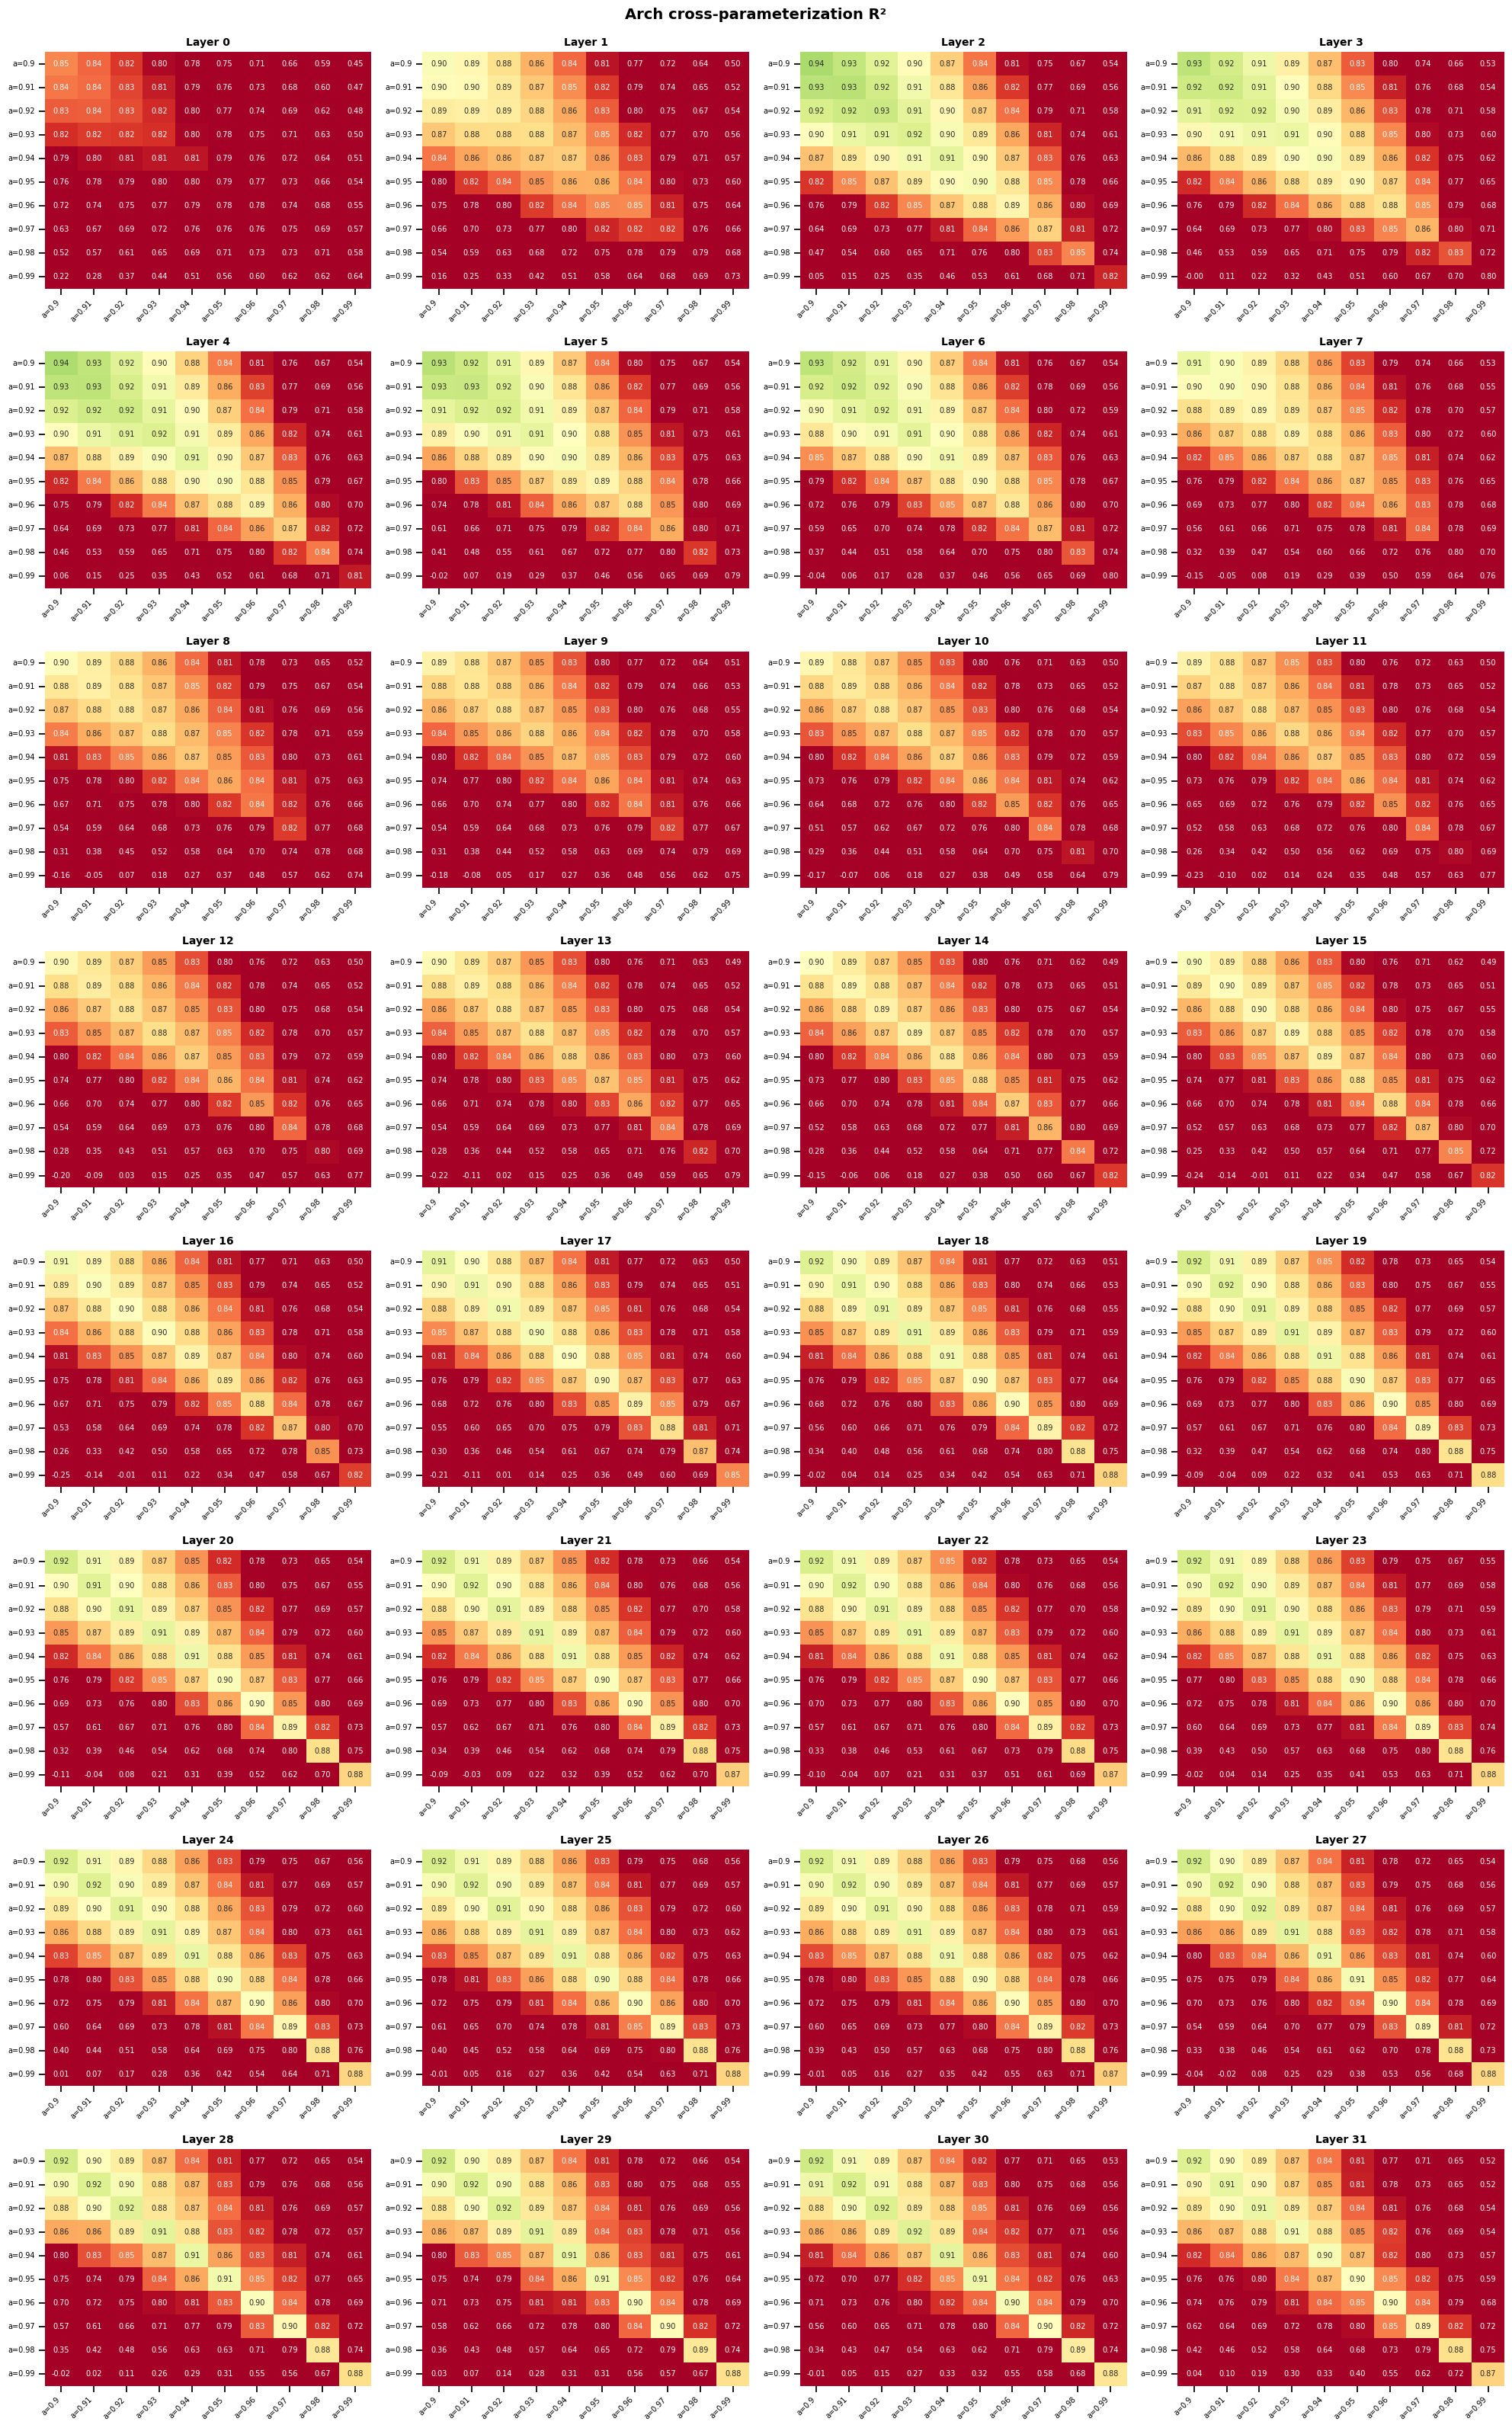

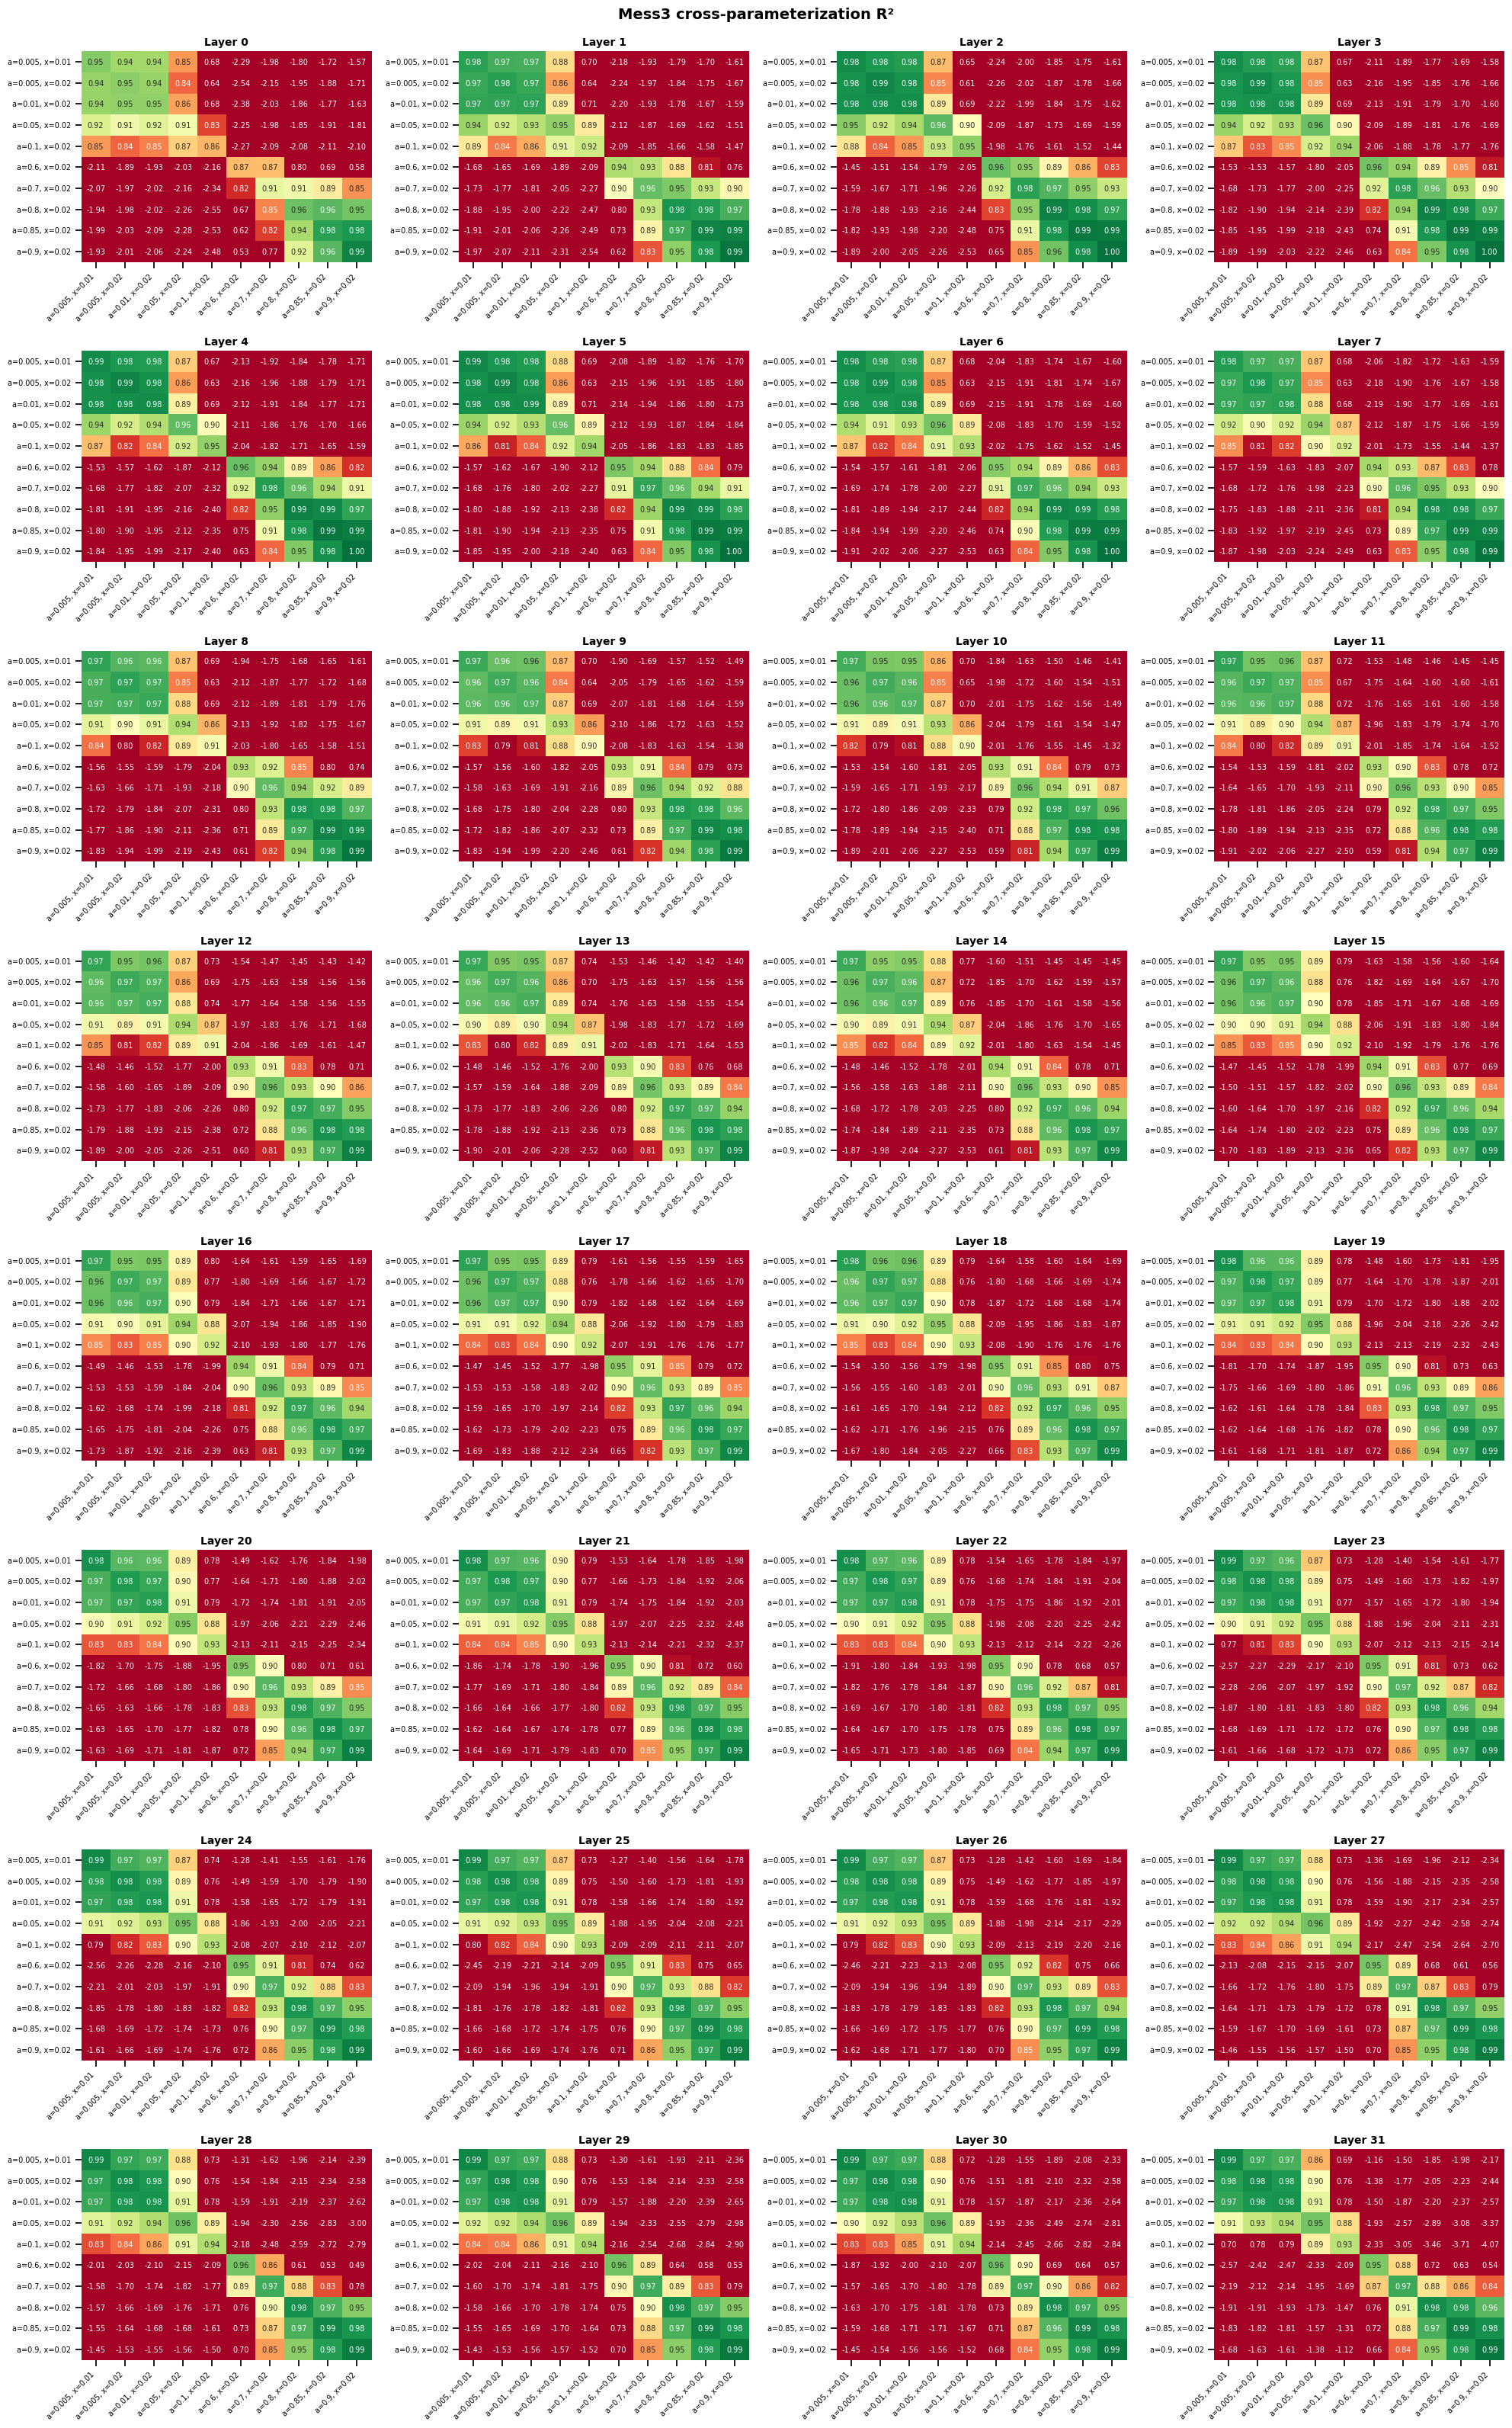

In [8]:
for hmm_name, cfg in HMMS.items():
    param_labels = [cfg['label_fn'](p) for p in cfg['params']]
    sub = cross_df[cross_df['hmm'] == hmm_name]
    if len(sub) == 0:
        continue

    n_cols = 4
    n_rows = (len(LAYERS) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    for li, layer in enumerate(LAYERS):
        ax = axes.flat[li]
        layer_sub = sub[sub['layer'] == layer]
        pivot = layer_sub.groupby(['train', 'test'])['R2'].mean().unstack()
        pivot = pivot.reindex(index=param_labels, columns=param_labels)

        sns.heatmap(pivot, cmap='RdYlGn', vmin=0.8, vmax=1.0,
                    ax=ax, square=False, cbar=False,
                    xticklabels=param_labels, yticklabels=param_labels,
                    annot=True, fmt='.2f', annot_kws={'fontsize': 7})
        ax.set_title(f'Layer {layer}', fontweight='bold', fontsize=10)
        ax.tick_params(labelsize=7)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_xlabel(''); ax.set_ylabel('')

    for li in range(len(LAYERS), n_rows * n_cols):
        axes.flat[li].set_visible(False)

    fig.suptitle(f'{hmm_name} cross-parameterization R²', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


## Ground-truth belief cross-predictability

GT Mess3: 100%|██████████| 100/100 [01:01<00:00,  1.63it/s]


Ground-truth: 5000 rows


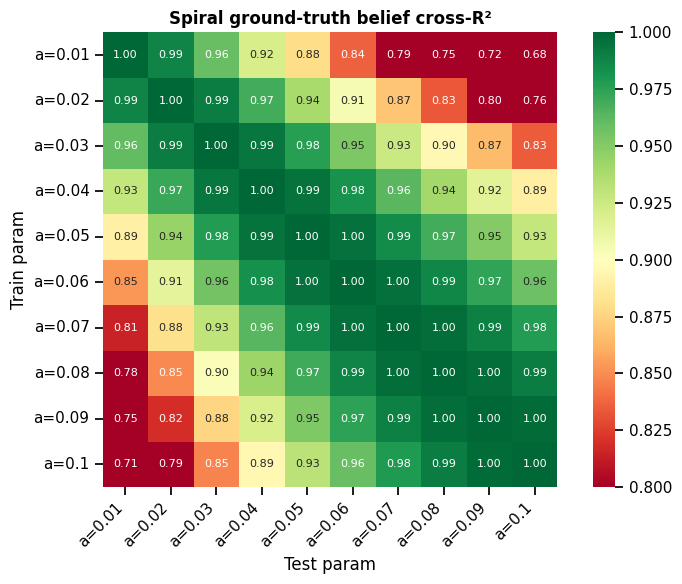

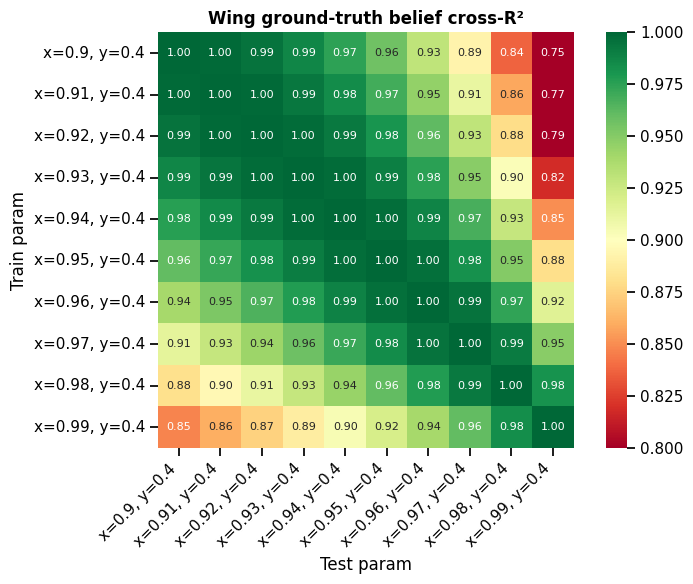

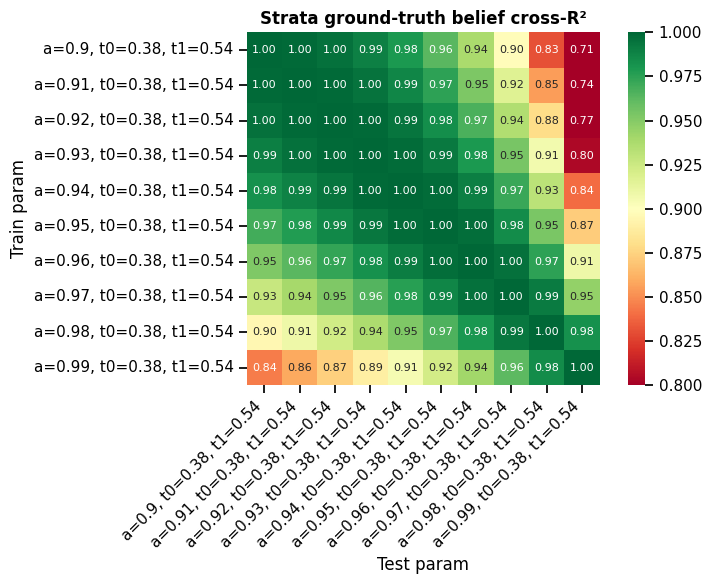

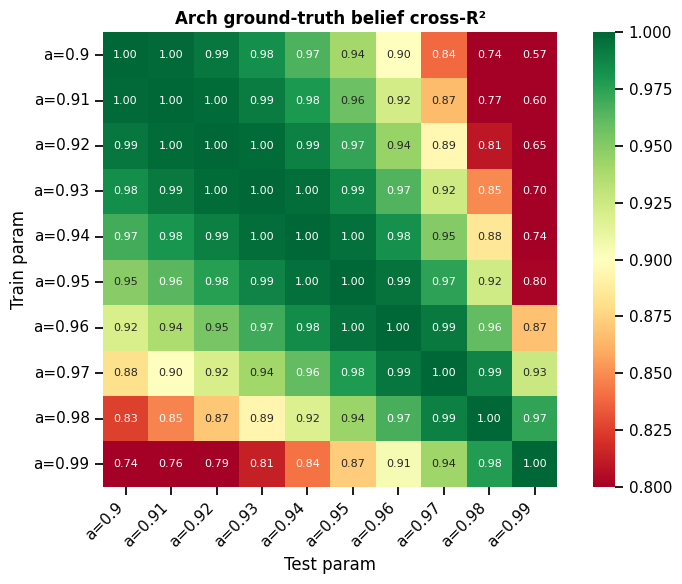

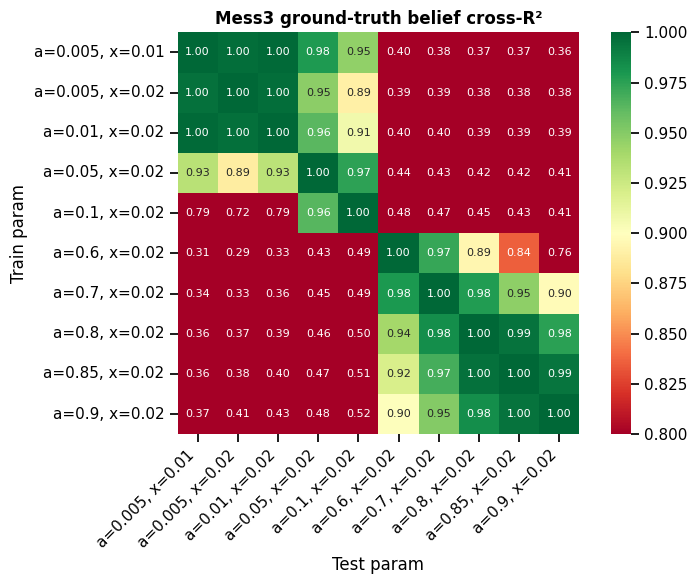

In [9]:
gt_rows = []

for hmm_name, cfg in HMMS.items():
    param_labels = [cfg['label_fn'](p) for p in cfg['params']]
    pbar = tqdm(total=len(cfg['params']) * N_SEEDS, desc=f'GT {hmm_name}')

    for param_train in cfg['params']:
        label_train = cfg['label_fn'](param_train)
        T_train = cfg['fn'](*param_train)
        T_train_stack = np.stack(T_train)
        pi_train = stationary_distribution(T_train)

        for seed in range(N_SEEDS):
            tokens = sample_hmm_sequence(T_train, pi_train, SEQ_LEN, seed=seed)
            tok_i64 = tokens.astype(np.int64)
            b_train = full_bayesian_beliefs_numba(tok_i64, T_train_stack, pi_train)
            b_train = b_train[PROBE_START:]

            idx_tr, idx_te = train_test_split(
                np.arange(len(b_train)), train_size=TRAIN_FRAC, random_state=seed)

            X_tr = torch.tensor(b_train[idx_tr], device=device, dtype=torch.float32)
            X_tr_b = torch.cat([X_tr, torch.ones(len(X_tr), 1, device=device)], dim=1)
            P = torch.linalg.pinv(X_tr_b)

            for param_test in cfg['params']:
                label_test = cfg['label_fn'](param_test)
                T_test = cfg['fn'](*param_test)
                T_test_stack = np.stack(T_test)
                pi_test = stationary_distribution(T_test)

                b_test = full_bayesian_beliefs_numba(tok_i64, T_test_stack, pi_test)
                b_test = b_test[PROBE_START:]

                Y_tr = torch.tensor(b_test[idx_tr], device=device, dtype=torch.float32)
                Y_te = torch.tensor(b_test[idx_te], device=device, dtype=torch.float32)

                W = P @ Y_tr
                X_te = torch.tensor(b_train[idx_te], device=device, dtype=torch.float32)
                X_te_b = torch.cat([X_te, torch.ones(len(X_te), 1, device=device)], dim=1)
                pred = X_te_b @ W

                ss_res = ((Y_te - pred) ** 2).sum().item()
                ss_tot = ((Y_te - Y_te.mean(0)) ** 2).sum().item()

                gt_rows.append({
                    'hmm': hmm_name, 'train': label_train, 'test': label_test,
                    'seed': seed, 'R2': 1.0 - ss_res / ss_tot,
                    'self': label_train == label_test,
                })

            pbar.update(1)
    pbar.close()

gt_df = pd.DataFrame(gt_rows)
gt_df.to_csv(os.path.join(RESULTS_DIR, 'gt_cross_qwen35_9b.csv'), index=False)
print(f'Ground-truth: {len(gt_df)} rows')

# Plot per HMM
for hmm_name, cfg in HMMS.items():
    param_labels = [cfg['label_fn'](p) for p in cfg['params']]
    sub = gt_df[gt_df['hmm'] == hmm_name]
    pivot = sub.groupby(['train', 'test'])['R2'].mean().unstack()
    pivot = pivot.reindex(index=param_labels, columns=param_labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, cmap='RdYlGn', vmin=0.8, vmax=1.0,
                ax=ax, square=True, annot=True, fmt='.2f',
                xticklabels=param_labels, yticklabels=param_labels,
                annot_kws={'fontsize': 8})
    ax.set_title(f'{hmm_name} ground-truth belief cross-R²', fontweight='bold')
    ax.set_xlabel('Test param'); ax.set_ylabel('Train param')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()


## Cross-R² correlation with ground-truth

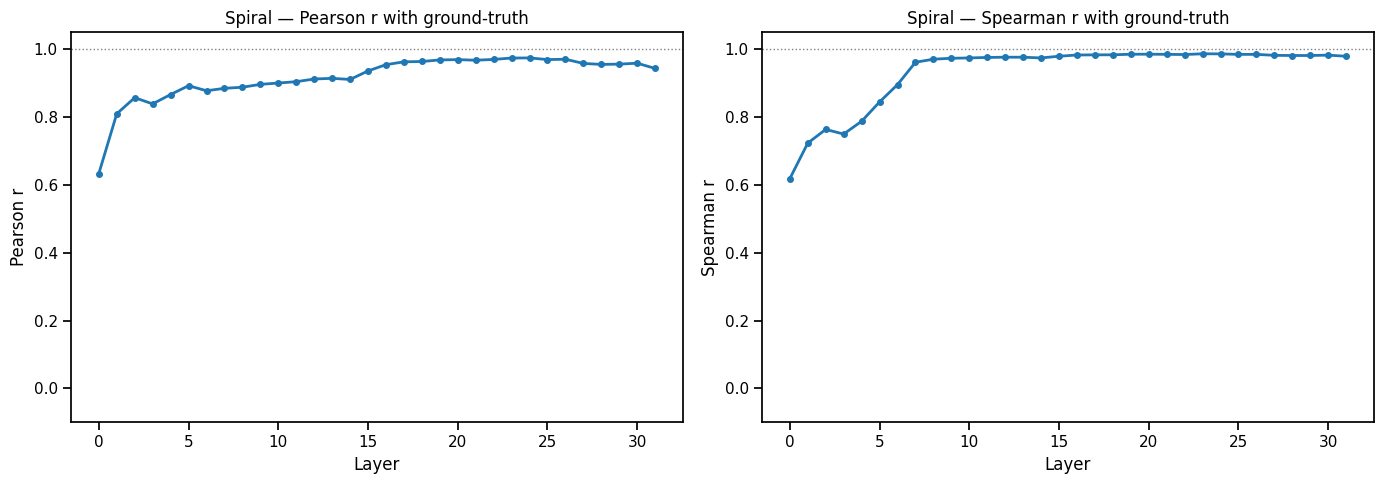

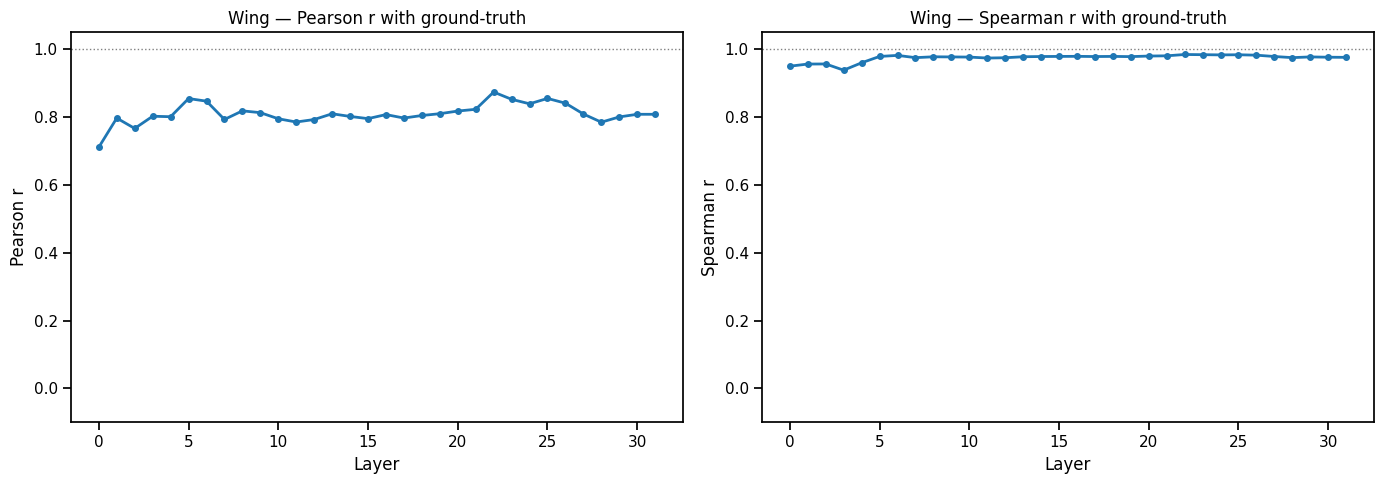

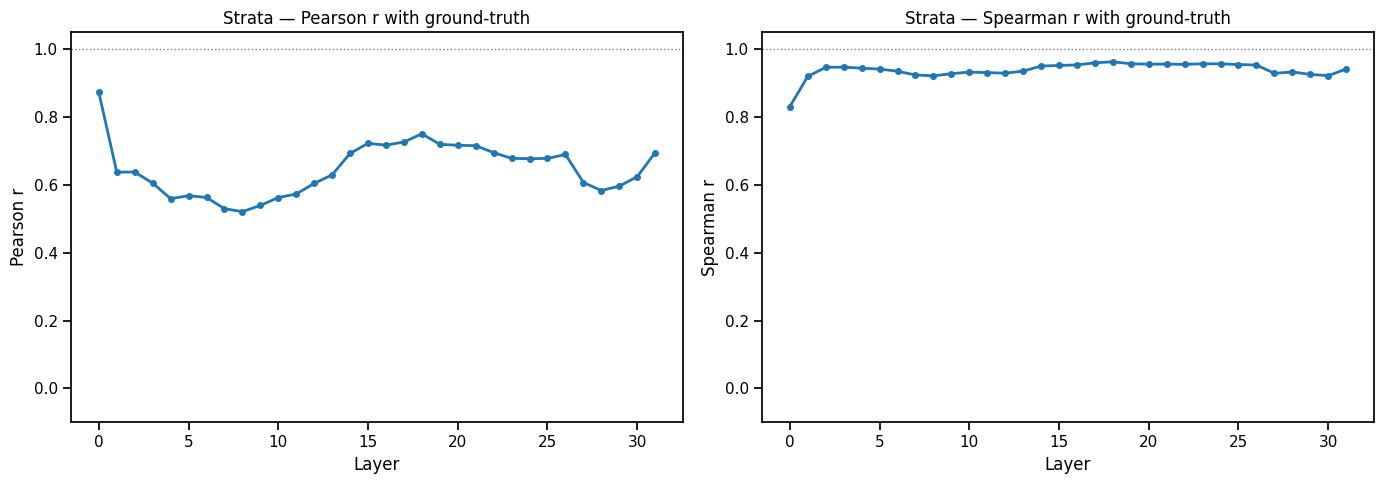

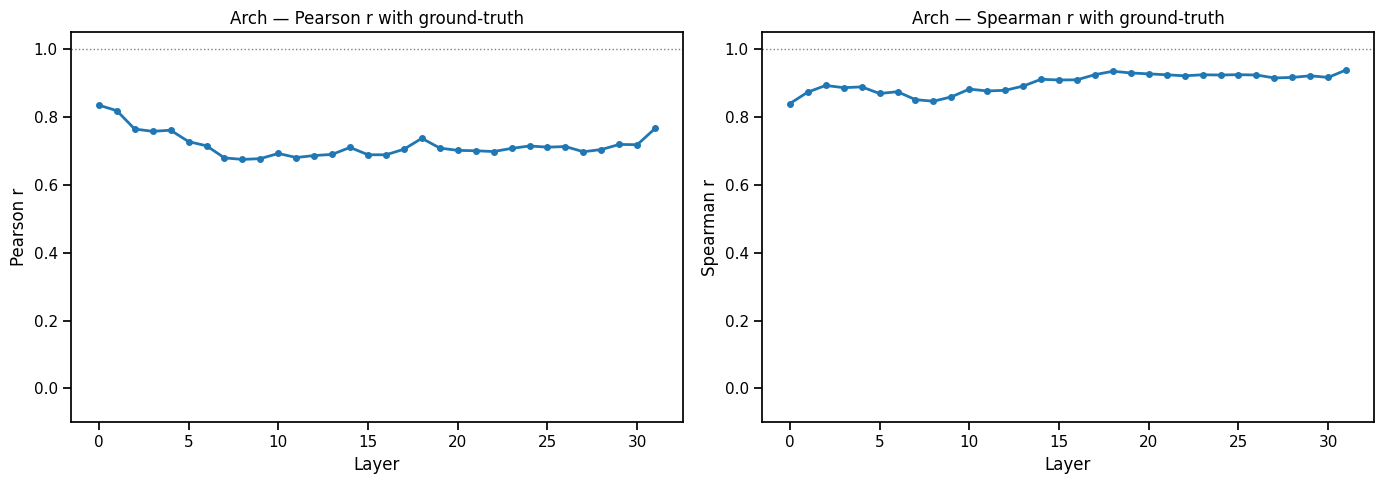

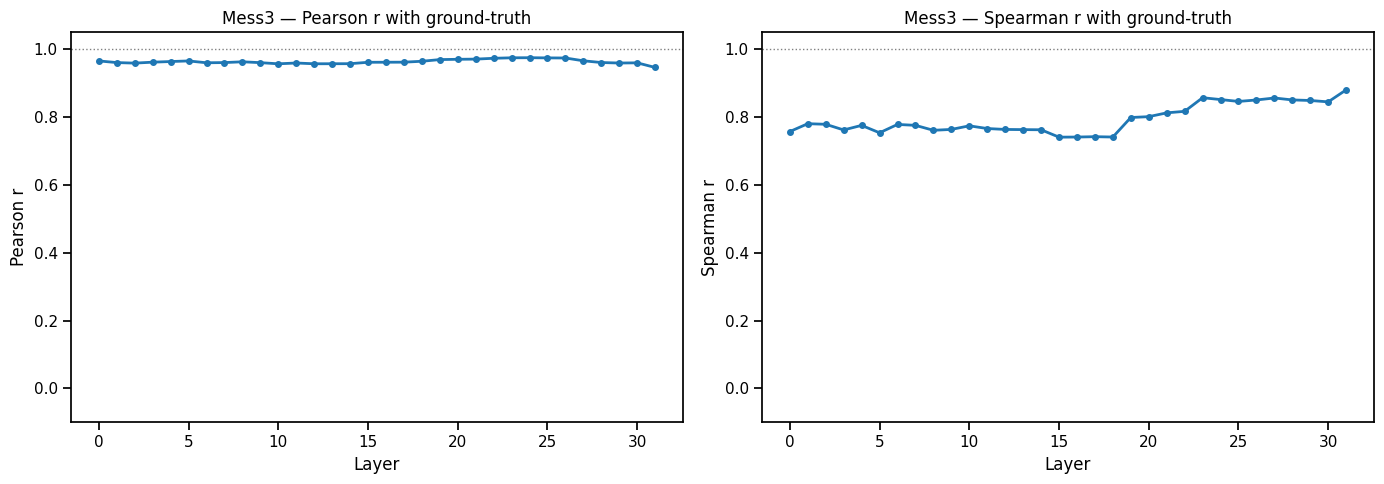

In [10]:
from scipy.stats import spearmanr

for hmm_name, cfg in HMMS.items():
    param_labels = [cfg['label_fn'](p) for p in cfg['params']]
    gt_sub = gt_df[gt_df['hmm'] == hmm_name]
    cross_sub = cross_df[cross_df['hmm'] == hmm_name]
    if len(cross_sub) == 0:
        continue

    gt_pivot = gt_sub.groupby(['train', 'test'])['R2'].mean().unstack()
    gt_pivot = gt_pivot.reindex(index=param_labels, columns=param_labels)
    gt_vec = gt_pivot.values.flatten()

    pearson_corrs = []
    spearman_corrs = []
    for layer in LAYERS:
        layer_sub = cross_sub[cross_sub['layer'] == layer]
        pivot = layer_sub.groupby(['train', 'test'])['R2'].mean().unstack()
        pivot = pivot.reindex(index=param_labels, columns=param_labels)
        vec = pivot.values.flatten()
        pearson_corrs.append(np.corrcoef(vec, gt_vec)[0, 1])
        spearman_corrs.append(spearmanr(vec, gt_vec).correlation)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, corrs, label in [(axes[0], pearson_corrs, 'Pearson r'), (axes[1], spearman_corrs, 'Spearman r')]:
        ax.plot(LAYERS, corrs, 'o-', lw=2, markersize=4, color='#1f77b4')
        ax.set_xlabel('Layer'); ax.set_ylabel(label)
        ax.set_title(f'{hmm_name} — {label} with ground-truth')
        ax.axhline(1.0, color='gray', ls=':', lw=1)
        ax.set_ylim(-0.1, 1.05)
    plt.tight_layout(); plt.show()
